# MLB Hugging Face strikeout quote backtest

Score the frozen 2018–2025 game-log NB (`nb_k_v1`) against SmartStake as-of strikeout quotes on **2026 holdout starts**.

This notebook does **not** refit the model and does **not** overwrite the 2018–2025 store. It loads cached starter logs + HF quotes, builds lagged features from each quoted pitcher's history, and scores one evaluation window.

Betting emulates a live card: at the last pre-cutoff quote, price **over and under at posted juice**, and take **at most one side** only if EV is strictly positive. Flat 1u. That P/L is still a quoted-price simulation (assumed fills at the as-of tick), not realized bankroll ROI.


## Evaluation window

Change `WINDOW` below. Default is **one week** so the notebook finishes quickly.

| `WINDOW` | What it keeps |
|---|---|
| `"game"` | first quoted game on `WINDOW_START` (or the first HF quote) |
| `"week"` | 7 calendar days from that origin |
| `"month"` | rest of that calendar month |
| `"full"` | every cached HF quote (Mar–Jul 2026) |

Optional: set `WINDOW_START = "2026-04-01"` to move the origin, or `GAME_PK = 123456` when `WINDOW == "game"`.

`MIN_EV = 0.0` means any strictly +EV bet after juice. Raise it (e.g. `0.02`) to require a 2% edge.


In [8]:
WINDOW = "full"  # "game" | "week" | "month" | "full"
WINDOW_START = None  # e.g. "2026-04-01"; None = first HF quote
GAME_PK = None  # only used when WINDOW == "game"
MIN_EV = 0.00  # require EV > this (0 = any +EV after juice)
STAKE = 1.0  # flat units per +EV bet
BOOKS = ("novig", "prophetx", "underdog", "fanduel", "draftkings", "prizepicks")


In [9]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("/Users/alexgonzalez/Documents/nba_quant")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.mlb.cli import _prepare_train_frame
from src.mlb.config import load_config
from src.mlb.evaluation.backtest import _ensure_prediction_pmf, _score_predictions
from src.mlb.evaluation.market import compare_market, simulate_plus_ev_bets
from src.mlb.models.calibration import randomized_pit
from src.mlb.models.serialize import as_strikeout_model, load_model
from src.mlb.models.strikeouts import predict_strikeout_pmf
from src.mlb.pipeline.hf_tables import assemble_windowed_hf_tables
from src.mlb.schemas import PMF_COLUMNS

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

config = load_config(ROOT / "config" / "mlb.yaml")
artifact = ROOT / "artifacts" / "mlb" / "strikeouts" / f"{config.model_version}.pkl"
if not artifact.exists():
    raise FileNotFoundError(f"missing strikeout artifact {artifact}")
model = as_strikeout_model(load_model(artifact))

tables, window_meta = assemble_windowed_hf_tables(
    config,
    window=WINDOW,
    window_start=WINDOW_START,
    game_pk=GAME_PK,
)
quotes = tables["market_quotes"]
book_col = "sportsbook" if "sportsbook" in quotes.columns else "book"
labels = quotes[book_col].astype(str).str.lower()
keep = labels.map(lambda book: any(book == name or book.startswith(name) for name in BOOKS))
quotes = quotes.loc[keep].copy()
print("books", sorted(labels.loc[keep].unique()))
print("Saved model:", artifact)
print("method:", model.method, " rank:", getattr(model, "matrix_rank", None))
print("window:", dict(window_meta))
print("feature starts (quoted pitchers, full history):", len(tables["pitcher_starts"]))
print("mapped as-of quotes:", len(quotes))


books ['draftkings', 'draftkings6_best', 'fanduel', 'novig', 'prizepicks_best', 'prophetx', 'underdog_dfs_best']
Saved model: /Users/alexgonzalez/Documents/nba_quant/artifacts/mlb/strikeouts/nb_k_v1.pkl
method: glm  rank: 9
window: {'window': 'full', 'start': '2026-03-21 17:05:00+00:00', 'end': '2026-07-05 17:35:00+00:00', 'n_quotes': 128407, 'n_games': 1101, 'n_players': 251, 'n_mapped': 91601, 'n_feature_starts': 19399, 'match_rate': 0.7133645362012975}
feature starts (quoted pitchers, full history): 19399
mapped as-of quotes: 11732


Features are built on each quoted pitcher's **full** start history. Only the windowed 2026 starts are scored.


In [10]:
panel = _prepare_train_frame(tables, config)
keys = quotes[["game_pk", "pitcher_id"]].drop_duplicates()
target = panel.merge(keys, on=["game_pk", "pitcher_id"], how="inner")
if target.empty:
    raise ValueError("no panel rows matched the windowed quotes")

preds = predict_strikeout_pmf(model, target, config)
preds = _ensure_prediction_pmf(preds, target, config)
y = pd.to_numeric(preds["strikeouts"], errors="coerce").to_numpy(dtype=float)
scores = _score_predictions(preds, y, config, np.random.default_rng(config.seed))

print(f"scored starts: {len(preds)}")
print(
    "actual K mean/sd:",
    f"{np.nanmean(y):.2f} / {np.nanstd(y):.2f}",
    "  E[K] mean/sd:",
    f"{preds['expected_k'].mean():.2f} / {preds['expected_k'].std():.2f}",
)
print(pd.Series(scores, name="score").to_string())
display_cols = [
    c
    for c in (
        "game_date",
        "pitcher_id",
        "strikeouts",
        "expected_k",
        "p_over_4_5",
        "p_over_5_5",
        "p_over_6_5",
        "pi_lower",
        "pi_upper",
    )
    if c in preds.columns
]
preds[display_cols].sort_values("game_date").head(12)


GLM optimizer did not converge after 11 iterations; fold=? intercept_only=True method=glm
GLM optimizer did not converge after 17 iterations; fold=? intercept_only=False method=glm
GLM optimizer did not converge after 10 iterations; fold=? intercept_only=False method=glm
GLM optimizer did not converge after 75 iterations; fold=? intercept_only=False method=glm
GLM optimizer did not converge after 68 iterations; fold=? intercept_only=False method=glm
GLM optimizer did not converge after 62 iterations; fold=? intercept_only=False method=glm
GLM optimizer did not converge after 69 iterations; fold=? intercept_only=False method=glm
GLM optimizer did not converge after 117 iterations; fold=? intercept_only=False method=glm
GLM optimizer did not converge after 47 iterations; fold=? intercept_only=False method=glm
GLM optimizer did not converge after 99 iterations; fold=? intercept_only=False method=glm
GLM optimizer did not converge after 118 iterations; fold=? intercept_only=False method=gl

scored starts: 1554
actual K mean/sd: 4.87 / 2.39   E[K] mean/sd: 5.14 / 1.07
n                       1,554.000
pmf_nll                     2.202
discrete_crps               1.245
mae                         1.789
rmse                        2.246
coverage_80                 0.877
width_80                    6.008
pit_mean                    0.472
brier_4_5                   0.231
brier_5_5                   0.209
brier_6_5                   0.163
calibration_slope           0.998
calibration_intercept      -0.155


,game_date,pitcher_id,strikeouts,expected_k,p_over_4_5,p_over_5_5,p_over_6_5,pi_lower,pi_upper
0,2026-03-26,671096,4,4.609,0.483,0.319,0.192,2.000,8.000
100,2026-03-26,571510,7,4.355,0.437,0.277,0.160,2.000,7.000
140,2026-03-26,686613,9,5.986,0.697,0.543,0.392,3.000,9.000
239,2026-03-26,676917,5,3.534,0.284,0.154,0.075,1.000,6.000
310,2026-03-26,676979,8,6.418,0.749,0.605,0.456,3.000,10.000
365,2026-03-26,543135,7,5.258,0.592,0.427,0.282,2.000,8.000
704,2026-03-26,669461,2,3.848,0.342,0.198,0.104,1.000,7.000
940,2026-03-26,694819,11,6.060,0.706,0.554,0.403,3.000,10.000
1051,2026-03-26,642547,7,5.408,0.616,0.451,0.304,2.000,9.000
1100,2026-03-26,601713,4,5.526,0.633,0.470,0.322,3.000,9.000


## Live +EV bets

For each as-of quote, EV uses the **posted** over/under decimal (juice on), not the de-vigged fair line. Skip anything with EV ≤ `MIN_EV`. If both sides clear, take the larger EV. Calibration above is still on every mapped start; the table and P/L below are only the bets you would place.


In [11]:
market = compare_market(preds, quotes, config)
if market.empty:
    raise ValueError("compare_market returned no rows; check quote mapping")

screened, bet_summary = simulate_plus_ev_bets(market, min_ev=MIN_EV, stake=STAKE)
bets = screened.loc[screened["bet_side"].astype(str) != ""].copy()

print("roi_type: quoted_price_simulation (posted juice, assumed fill, not realized ROI)")
print(pd.Series(bet_summary, name="live +EV").to_string())
print(
    f"screened {int(bet_summary['n_quotes'])} quotes → "
    f"{int(bet_summary['n_bets'])} bets, "
    f"{int(bet_summary['n_skipped'])} skips "
    f"(EV <= {MIN_EV:g})"
)
if bets.empty:
    print("No +EV bets in this window.")
    screened[["ev_over", "ev_under"]].describe().loc[["mean", "50%", "max"]]
else:
    show = [
        c
        for c in (
            "game_date",
            "pitcher_id",
            "line",
            "bet_side",
            "bet_decimal",
            "bet_ev",
            "strikeouts",
            "expected_k",
            "result",
            "pnl",
            "sportsbook",
        )
        if c in bets.columns
    ]
    sort_cols = [c for c in ("game_date", "bet_ev") if c in bets.columns]
    bets.sort_values(sort_cols, ascending=[True, False][: len(sort_cols)])[show]


roi_type: quoted_price_simulation (posted juice, assumed fill, not realized ROI)
n_quotes       10,597.000
n_bets          7,793.000
n_skipped       2,804.000
n_wins          3,911.000
n_losses        3,773.000
n_pushes          109.000
units_staked    7,793.000
units_pnl        -148.560
roi                -0.019
hit_rate            0.509
mean_ev             0.126
min_ev              0.000
stake               1.000
screened 10597 quotes → 7793 bets, 2804 skips (EV <= 0)


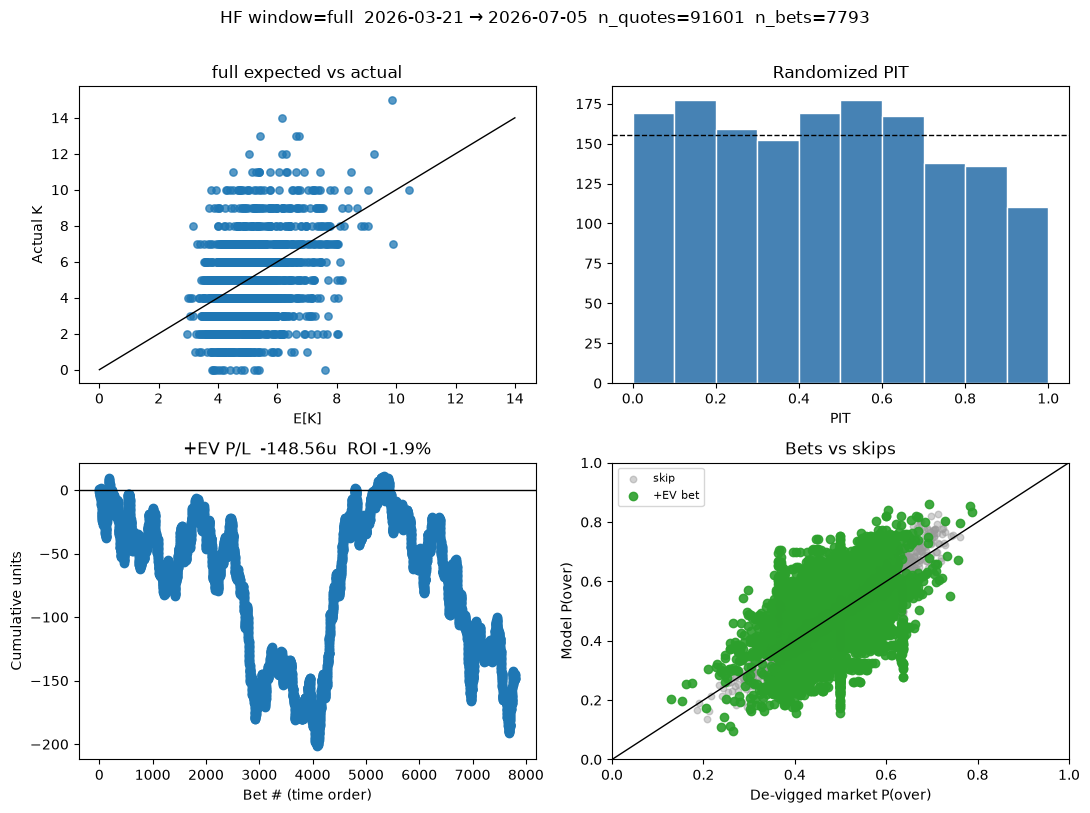

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].scatter(preds["expected_k"], preds["strikeouts"], s=28, alpha=0.75)
lims = [0, 14]
axes[0, 0].plot(lims, lims, color="black", lw=1)
axes[0, 0].set_xlabel("E[K]")
axes[0, 0].set_ylabel("Actual K")
axes[0, 0].set_title(f"{window_meta['window']} expected vs actual")

pmf = preds.loc[:, list(PMF_COLUMNS)].to_numpy(dtype=float)
pit = randomized_pit(pmf, y, np.random.default_rng(config.seed))
axes[0, 1].hist(pit, bins=10, range=(0, 1), color="steelblue", edgecolor="white")
axes[0, 1].axhline(len(pit) / 10, color="black", lw=1, ls="--")
axes[0, 1].set_title("Randomized PIT")
axes[0, 1].set_xlabel("PIT")

taken = bets.copy()
if taken.empty:
    axes[1, 0].text(0.5, 0.5, "no +EV bets", ha="center", va="center")
    axes[1, 0].set_axis_off()
else:
    time_col = next(
        (c for c in ("prediction_cutoff_utc", "game_date") if c in taken.columns),
        None,
    )
    if time_col is not None:
        taken = taken.sort_values(time_col)
    taken = taken.reset_index(drop=True)
    taken["cum_pnl"] = taken["pnl"].cumsum()
    axes[1, 0].plot(np.arange(1, len(taken) + 1), taken["cum_pnl"], marker="o")
    axes[1, 0].axhline(0, color="black", lw=1)
    axes[1, 0].set_xlabel("Bet # (time order)")
    axes[1, 0].set_ylabel("Cumulative units")
    axes[1, 0].set_title(
        f"+EV P/L  {bet_summary['units_pnl']:+.2f}u  "
        f"ROI {bet_summary['roi']:.1%}"
        if np.isfinite(bet_summary["roi"])
        else "+EV P/L"
    )

skip = screened["bet_side"].astype(str) == ""
axes[1, 1].scatter(
    screened.loc[skip, "market_p_over"],
    screened.loc[skip, "model_p_over"],
    s=22,
    alpha=0.45,
    color="0.6",
    label="skip",
)
if not skip.all():
    axes[1, 1].scatter(
        screened.loc[~skip, "market_p_over"],
        screened.loc[~skip, "model_p_over"],
        s=36,
        alpha=0.9,
        color="C2",
        label="+EV bet",
    )
axes[1, 1].plot([0, 1], [0, 1], color="black", lw=1)
axes[1, 1].set_xlabel("De-vigged market P(over)")
axes[1, 1].set_ylabel("Model P(over)")
axes[1, 1].set_title("Bets vs skips")
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend(loc="upper left", fontsize=8)

fig.suptitle(
    f"HF window={window_meta['window']}  {window_meta['start'][:10]} → {window_meta['end'][:10]}  "
    f"n_quotes={int(window_meta['n_mapped'])}  n_bets={int(bet_summary['n_bets'])}",
    y=1.01,
)
fig.tight_layout()
plt.show()


In [13]:
book_col = next((c for c in ("sportsbook", "book") if c in screened.columns), None)
if book_col is None:
    raise ValueError("no sportsbook column on screened quotes")

frame = screened.copy()
frame["_book"] = frame[book_col].astype(str).str.lower()
rows = []
for book, grp in frame.groupby("_book", dropna=False):
    placed = grp.loc[grp["bet_side"].astype(str) != ""]
    decided = placed.loc[placed["result"].isin(["win", "loss"])]
    staked = float(placed["stake"].sum()) if not placed.empty else 0.0
    pnl = float(placed["pnl"].sum()) if not placed.empty else 0.0
    rows.append(
        {
            "sportsbook": book,
            "n_quotes": int(len(grp)),
            "n_bets": int(len(placed)),
            "n_skipped": int(len(grp) - len(placed)),
            "n_wins": int((placed["result"] == "win").sum()),
            "n_losses": int((placed["result"] == "loss").sum()),
            "units_staked": staked,
            "units_pnl": pnl,
            "roi": (pnl / staked) if staked > 0 else float("nan"),
            "hit_rate": float((decided["result"] == "win").mean()) if len(decided) else float("nan"),
            "mean_ev": float(placed["bet_ev"].mean()) if not placed.empty else float("nan"),
        }
    )
by_book = (
    pd.DataFrame(rows)
    .sort_values(["n_bets", "roi"], ascending=[False, False])
    .reset_index(drop=True)
)
print("quoted-price simulation ROI by book (+EV bets only)")
by_book


quoted-price simulation ROI by book (+EV bets only)


,sportsbook,n_quotes,n_bets,n_skipped,n_wins,n_losses,units_staked,units_pnl,roi,hit_rate,mean_ev
0,novig,2524,1968,556,970,998,"1,968.000",-24.142,-0.012,0.493,0.140
1,draftkings,2013,1533,480,778,755,"1,533.000",-42.858,-0.028,0.508,0.125
2,prizepicks_best,1852,1300,552,637,554,"1,300.000",-12.550,-0.010,0.535,0.114
3,prophetx,1611,1236,375,595,641,"1,236.000",-72.636,-0.059,0.481,0.131
4,fanduel,1322,945,377,481,464,945.000,-14.434,-0.015,0.509,0.122
5,draftkings6_best,779,509,270,282,227,509.000,8.470,0.017,0.554,0.111
6,underdog_dfs_best,496,302,194,168,134,302.000,9.590,0.032,0.556,0.111
